In [2]:
# Housing price over time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")
sns.set(font_scale=1.1)

df = pd.read_csv("Housing-selected-columns.csv")


In [4]:
# Inspect data
df.head()
df.tail()
df.shape
df.info()
df.describe()

df.isna().sum()
df.duplicated().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   price            545 non-null    int64 
 1   area             545 non-null    int64 
 2   bedrooms         545 non-null    int64 
 3   bathrooms        545 non-null    int64 
 4   stories          545 non-null    int64 
 5   mainroad         545 non-null    object
 6   guestroom        545 non-null    object
 7   basement         545 non-null    object
 8   hotwaterheating  545 non-null    object
 9   airconditioning  545 non-null    object
dtypes: int64(5), object(5)
memory usage: 42.7+ KB


0

In [5]:
# lean, strip, standardize, median imputation, date parse
# 3. Strip & standardize text columns
str_cols = df.select_dtypes(include="object").columns

for col in str_cols:
    df[col] = df[col].str.strip().str.lower()

# 4. Replace NaN numeric values with median (will be no-op if no NaNs)
num_cols = df.select_dtypes(include=["int64", "float64"]).columns

for col in num_cols:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)

# 5. Handle remaining missing values (categorical)
for col in str_cols:
    df[col] = df[col].fillna("unknown")


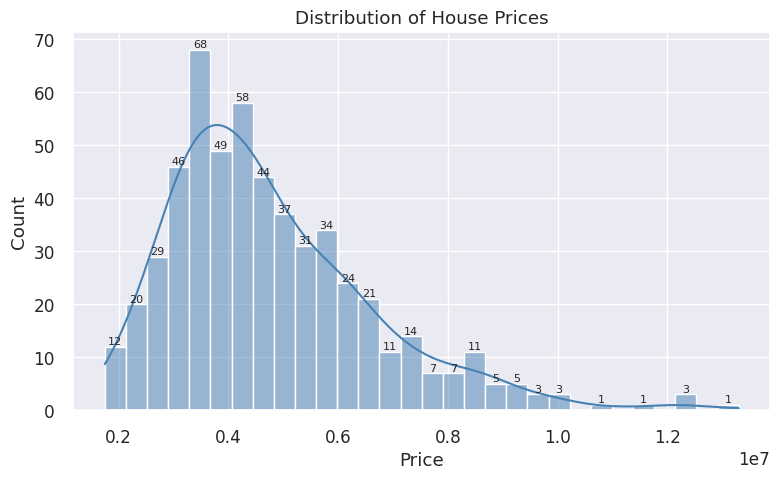

In [25]:
# Visualization 1 – Price distribution (KPI: price spread)
plt.figure(figsize=(8,5))
ax = sns.histplot(df["price"], bins=30, color="steelblue", kde=True)
plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Count")

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.text(p.get_x() + p.get_width()/2, height, f"{int(height)}",
                ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()


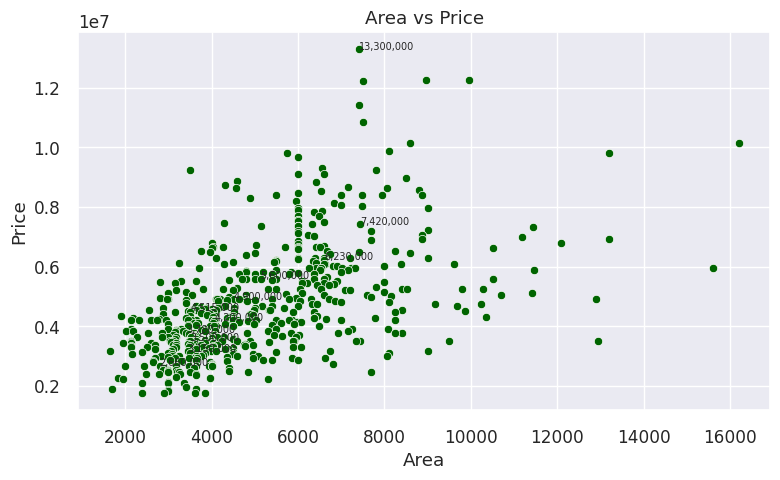

In [24]:
# Visualization 2 – Area vs price (KPI: economic driver)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,5))
ax = sns.scatterplot(data=df, x="area", y="price", color="darkgreen")
plt.title("Area vs Price")
plt.xlabel("Area")
plt.ylabel("Price")

for i in range(0, len(df), 50):
    ax.text(df["area"].iloc[i], df["price"].iloc[i],
            f"{df['price'].iloc[i]:,.0f}", fontsize=7)

plt.tight_layout()
plt.show()



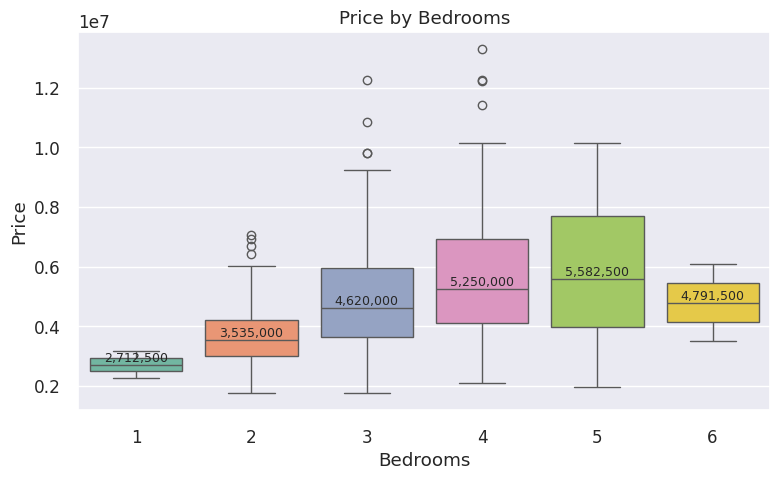

In [23]:
# Visualization 3 – Bedrooms & bathrooms vs price (KPI: structural impact)
plt.figure(figsize=(8,5))
ax = sns.boxplot(
    data=df,
    x="bedrooms",
    y="price",
    hue="bedrooms",
    palette="Set2",
    legend=False
)
plt.title("Price by Bedrooms")
plt.xlabel("Bedrooms")
plt.ylabel("Price")

medians = df.groupby("bedrooms")["price"].median()
for i, (bed, med) in enumerate(medians.items()):
    ax.text(i, med, f"{med:,.0f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()



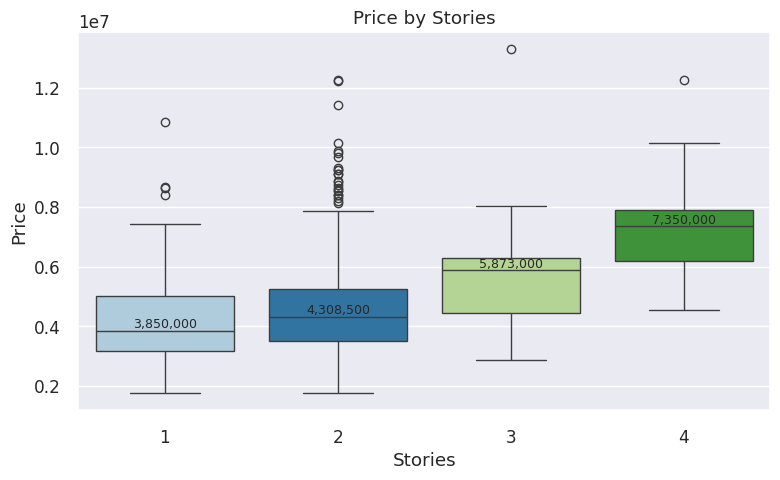

In [22]:
# Visualization 4 – Stories vs price (KPI: vertical expansion)
plt.figure(figsize=(8,5))
ax = sns.boxplot(
    data=df,
    x="stories",
    y="price",
    hue="stories",
    palette="Paired",
    legend=False
)
plt.title("Price by Stories")
plt.xlabel("Stories")
plt.ylabel("Price")

medians = df.groupby("stories")["price"].median()
for i, (story, med) in enumerate(medians.items()):
    ax.text(i, med, f"{med:,.0f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()


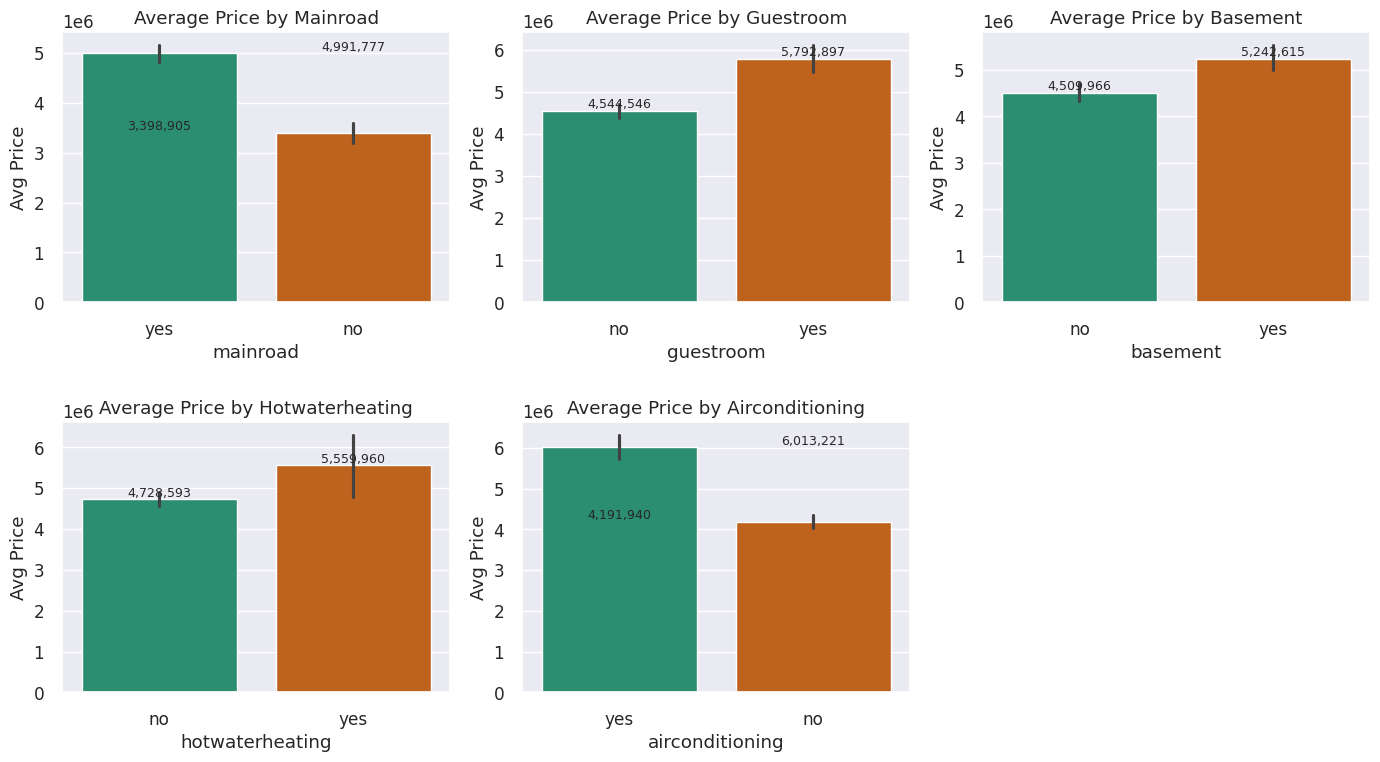

In [21]:
# Visualization 5 – Amenities vs price (KPI: “social/comfort” impact)
amenities = ["mainroad", "guestroom", "basement", "hotwaterheating", "airconditioning"]

plt.figure(figsize=(14,8))

for i, col in enumerate(amenities, 1):
    plt.subplot(2,3,i)
    ax = sns.barplot(
        data=df,
        x=col,
        y="price",
        estimator=np.mean,
        hue=col,
        palette="Dark2",
        legend=False
    )
    plt.title(f"Average Price by {col.capitalize()}")
    plt.xlabel(col)
    plt.ylabel("Avg Price")

    grouped = df.groupby(col)["price"].mean()
    for j, (cat, val) in enumerate(grouped.items()):
        ax.text(j, val, f"{val:,.0f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()



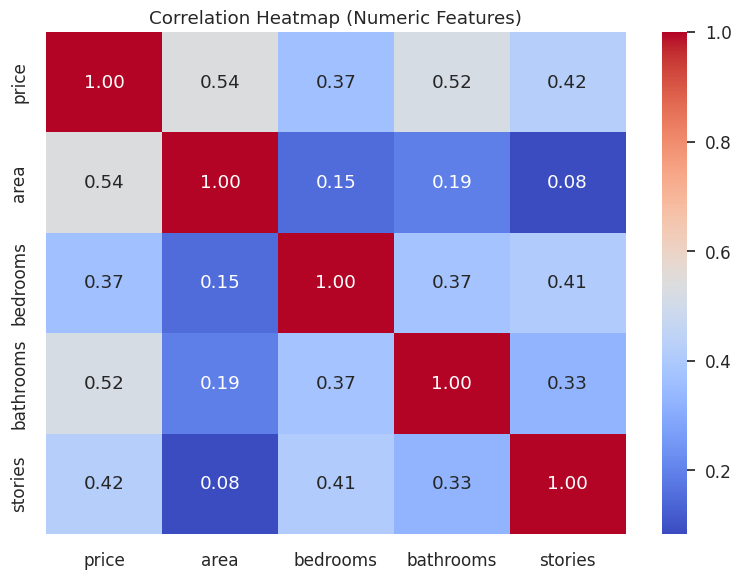

In [12]:
# Visualization 6 – Correlation heatmap (KPI: key numeric relationships)
plt.figure(figsize=(8,6))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap (Numeric Features)")
plt.tight_layout()
plt.show()


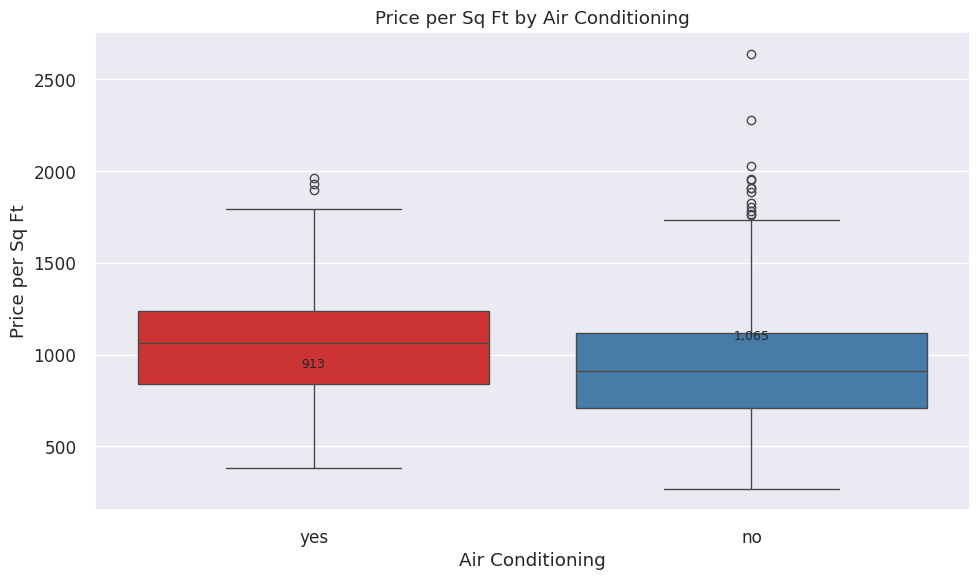

In [20]:
# Price per square foot with labels
df["price_per_sqft"] = df["price"] / df["area"]

plt.figure(figsize=(10,6))
ax = sns.boxplot(
    data=df,
    x="airconditioning",
    y="price_per_sqft",
    hue="airconditioning",
    palette="Set1",
    legend=False
)
plt.title("Price per Sq Ft by Air Conditioning")
plt.xlabel("Air Conditioning")
plt.ylabel("Price per Sq Ft")

grouped = df.groupby("airconditioning")["price_per_sqft"].median()
for i, (cat, med) in enumerate(grouped.items()):
    ax.text(i, med, f"{med:,.0f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()




In [27]:
exec_summary = """
Executive Summary

This housing dataset contains 545 properties with structural features (area,
bedrooms, bathrooms, stories) and amenity indicators (mainroad, guestroom,
basement, hotwaterheating, airconditioning).

Key Findings:
- Price strongly correlates with area, bathrooms, and number of stories.
- Amenities such as air conditioning, basements, and hot water heating increase
  average price.
- Mainroad access is associated with higher valuation due to accessibility.
- Price per square foot reveals efficiency differences across properties.

Overall:
The dataset is clean, contains no missing values, and shows clear relationships
between structural features, comfort amenities, and market price. These insights
support predictive modeling and pricing strategy development.
"""
print(exec_summary)



Executive Summary

This housing dataset contains 545 properties with structural features (area,
bedrooms, bathrooms, stories) and amenity indicators (mainroad, guestroom,
basement, hotwaterheating, airconditioning).

Key Findings:
- Price strongly correlates with area, bathrooms, and number of stories.
- Amenities such as air conditioning, basements, and hot water heating increase
  average price.
- Mainroad access is associated with higher valuation due to accessibility.
- Price per square foot reveals efficiency differences across properties.

Overall:
The dataset is clean, contains no missing values, and shows clear relationships
between structural features, comfort amenities, and market price. These insights
support predictive modeling and pricing strategy development.



In [36]:
# Load dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")
sns.set(font_scale=1.1)

df = pd.read_csv("Aspect-Based Sentiment Analysis on Generative AI.csv")


In [37]:
# Inspect dataset
df.head()
df.info()
df.describe(include="all")
df.isna().sum()
df.duplicated().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 704 entries, 0 to 703
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   ai_tools        704 non-null    object
 1   aspect          704 non-null    object
 2   review_text     704 non-null    object
 3   argument        703 non-null    object
 4   sentiment       704 non-null    object
 5   source_of_data  704 non-null    object
dtypes: object(6)
memory usage: 33.1+ KB


1

In [38]:
# Standardize and date parse
# Standardize string columns
str_cols = df.select_dtypes(include="object").columns

for col in str_cols:
    df[col] = df[col].str.strip().str.lower()

# Date parse (if you have a date column)
if "date" in df.columns:
    df["date"] = pd.to_datetime(df["date"], errors="coerce")


In [39]:
# Handle missing values and replace NaN numeric with median
# Numeric columns → median
num_cols = df.select_dtypes(include=["int64", "float64"]).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Categorical columns → 'unknown'
for col in str_cols:
    df[col] = df[col].fillna("unknown")


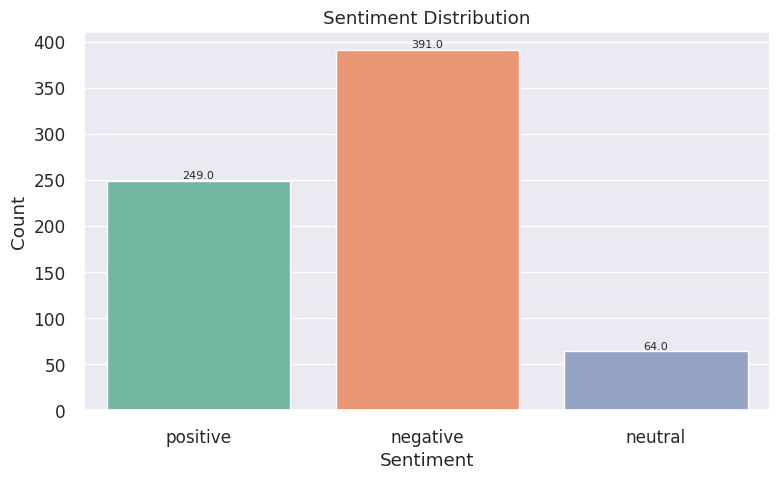

In [40]:
# Sentiment distribution (KPI: sentiment counts)
plt.figure(figsize=(8,5))
ax = sns.countplot(data=df, x="sentiment", hue="sentiment", palette="Set2", legend=False)
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

for p in ax.patches:
    h = p.get_height()
    ax.text(p.get_x() + p.get_width()/2, h, f"{h}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()


In [42]:
# Average sentiment over time (KPI: trend)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
if "date" in df.columns:
    sent_trend = (
        df.groupby("date")["sentiment_score"]
          .mean()
          .reset_index()
    )

    plt.figure(figsize=(10,5))
    ax = sns.lineplot(data=sent_trend, x="date", y="sentiment_score", color="darkblue")
    plt.title("Average Sentiment Score Over Time")
    plt.xlabel("Date")
    plt.ylabel("Mean Sentiment Score")

    step = max(1, len(sent_trend)//15)
    for i in range(0, len(sent_trend), step):
        ax.text(sent_trend["date"].iloc[i],
                sent_trend["sentiment_score"].iloc[i],
                f"{sent_trend['sentiment_score'].iloc[i]:.2f}",
                fontsize=8)

    plt.tight_layout()
    plt.show()


In [3]:
import numpy as np
import pandas as pd

np.random.seed(42)

n = 50000

# Basic demographics
respondent_id = np.arange(1, n+1)
age = np.random.randint(18, 71, size=n)

gender_choices = ["male", "female", "nonbinary", "prefer_not_to_say"]
gender = np.random.choice(gender_choices, size=n, p=[0.45, 0.45, 0.05, 0.05])

country_choices = ["usa", "uk", "india", "germany", "brazil", "japan", "nigeria", "canada", "australia"]
country = np.random.choice(country_choices, size=n)

education_choices = ["high_school", "bachelor", "master", "phd", "other"]
education_level = np.random.choice(education_choices, size=n, p=[0.3, 0.4, 0.2, 0.05, 0.05])

employment_choices = ["employed", "unemployed", "student", "self_employed", "retired"]
employment_status = np.random.choice(employment_choices, size=n, p=[0.55, 0.1, 0.15, 0.1, 0.1])

industry_choices = ["tech", "manufacturing", "finance", "healthcare", "education", "services", "government", "other"]
industry = np.random.choice(industry_choices, size=n)

ai_knowledge_choices = ["low", "medium", "high"]
ai_knowledge_level = np.random.choice(ai_knowledge_choices, size=n, p=[0.4, 0.4, 0.2])

year = np.random.choice([2023, 2024, 2025, 2026], size=n, p=[0.2, 0.3, 0.3, 0.2])

# Scores with correlations
base_optimism = np.where(ai_knowledge_level == "high", 3.8,
                  np.where(ai_knowledge_level == "medium", 3.2, 2.6))

age_factor = np.clip((40 - age) / 40, -0.5, 0.5)
ai_optimism_score = base_optimism + age_factor + np.random.normal(0, 0.6, size=n)
ai_optimism_score = np.clip(np.round(ai_optimism_score), 1, 5)

base_concern = np.where(industry == "manufacturing", 3.8,
                 np.where(industry == "services", 3.4,
                 np.where(industry == "tech", 2.8, 3.2)))

employment_factor = np.where(employment_status == "unemployed", 0.7,
                      np.where(employment_status == "student", -0.3,
                      np.where(employment_status == "retired", -0.5, 0.0)))

job_security_concern_score = base_concern + employment_factor + np.random.normal(0, 0.6, size=n)
job_security_concern_score = np.clip(np.round(job_security_concern_score), 1, 5)

believes_ai_will_create_jobs = np.where(ai_optimism_score >= 3, "yes", "no")
believes_ai_will_destroy_jobs = np.where(job_security_concern_score >= 3, "yes", "no")

support_ai_regulation = (
    2.5
    + (job_security_concern_score - 3) * 0.4
    + np.where(ai_knowledge_level == "high", 0.3, 0.0)
    + np.random.normal(0, 0.5, size=n)
)
support_ai_regulation = np.clip(np.round(support_ai_regulation), 1, 5)

# Build DataFrame
df = pd.DataFrame({
    "respondent_id": respondent_id,
    "age": age,
    "gender": gender,
    "country": country,
    "education_level": education_level,
    "employment_status": employment_status,
    "industry": industry,
    "ai_knowledge_level": ai_knowledge_level,
    "ai_optimism_score": ai_optimism_score,
    "job_security_concern_score": job_security_concern_score,
    "believes_ai_will_create_jobs": believes_ai_will_create_jobs,
    "believes_ai_will_destroy_jobs": believes_ai_will_destroy_jobs,
    "support_ai_regulation": support_ai_regulation,
    "year": year
})

# Save CSV
df.to_csv("public_opinion_ai_jobs.csv", index=False)

df.head()


,respondent_id,age,gender,country,education_level,employment_status,industry,ai_knowledge_level,ai_optimism_score,job_security_concern_score,believes_ai_will_create_jobs,believes_ai_will_destroy_jobs,support_ai_regulation,year
0,1,56,female,brazil,bachelor,employed,healthcare,high,4.0,3.0,yes,yes,2.0,2024
1,2,69,female,india,master,employed,finance,medium,3.0,3.0,yes,yes,3.0,2023
2,3,46,male,india,bachelor,employed,education,low,3.0,4.0,yes,yes,3.0,2026
3,4,32,female,germany,master,unemployed,services,medium,3.0,4.0,yes,yes,4.0,2023
4,5,60,male,india,high_school,retired,tech,low,1.0,4.0,no,yes,4.0,2026
